# 과제 1 — 시연 데이터 수집 및 Hub 업로드

**과제 내용**: 본인이 선택한 태스크(예: "큐브 집어 상자에 넣기")에 대해 **성공한 시연 50 에피소드**를 수집하고 Huggingface Hub에 업로드한다. 업로드 후 모든 에피소드를 검수해 문제가 없음을 확인한다.

### 작성 요령
- 이 노트북을 본인 GitHub 저장소(assignments 폴더)에 `assignment_1.ipynb`로 올리고 저장소 링크를 제출한다. (이후 모든 과제도 동일하게 제출 예정)
- 데이터 수집은 **터미널에서** `lerobot-record`로 진행하고 이 노트북에는 확인 코드와 검수 결과를 작성한다.
- 모든 코드 셀은 **실행한 뒤 출력 결과가 보이는 상태로** 커밋한다. (출력이 없으면 미제출로 간주)
- `[작성]` 표시가 있는 부분을 모두 채운다.

### 주의 사항
- 데이터셋은 **public**으로 업로드한다. (private이면 웹 뷰어와 채점 코드로 확인할 수 없음)
- 데이터셋 이름은 자유롭게 정하되, **0. 제출 정보 셀**에 적은 repo_id **하나만** 채점 대상으로 한다.
- 실패한 시연, 중간에 잘린 시연, 카메라 영상이 비정상인 시연은 **다시 녹화**한다. 이 데이터는 이후 과제 학습에 그대로 쓰이며, ACT는 시연을 그대로 모방하므로 나쁜 시연은 성공률을 직접 떨어뜨린다.
- `--dataset.single_task`에 넣는 태스크 문장은 **영어로** 쓴다. (예: "Pick up the cube and put it in the box.") 과제 5에서 학습할 SmolVLA는 이 문장을 언어 입력으로 받는데, SmolVLA의 언어 모델은 영어로 학습되었다.
- GitHub 저장소에는 데이터 파일을 올리지 않는다. (데이터는 Huggingface Hub에 올리고 노트북 파일만 올린다.)
- **마감 시각 이후의 커밋은 반영하지 않는다.**

## 0. 제출 정보

In [ ]:
# [작성] 본인 정보로 수정
STUDENT_ID = "2021136037"
NAME = "김진성"
HF_USER = "xx1541zz"

DATASET = f"xx1541zz/pick-cube_20261008_103849"   # 업로드한 데이터셋 repo_id
TASK = "Grab the black cube"   # 녹화 시 --dataset.single_task에 넣은 영어 문장 그대로

print("학번/이름      :", STUDENT_ID, NAME)
print("데이터셋 repo_id:", DATASET)
print("데이터셋 링크  :", f"https://huggingface.co/datasets/{DATASET}")
print("태스크 설명    :", TASK)

학번/이름      : 2021136037 김진성
데이터셋 repo_id: xx1541zz/pick-cube_20261008_103849
데이터셋 링크  : https://huggingface.co/datasets/xx1541zz/pick-cube_20261008_103849
태스크 설명    : Grab the black cube


In [ ]:
# Hub 접근 확인 — "OK"가 나와야 한다
import json
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import HfApi, hf_hub_download

api = HfApi()
try:
    repo_files = api.list_repo_files(DATASET, repo_type="dataset")
    print(f"OK  {DATASET}  (파일 {len(repo_files)}개)")
except Exception as e:
    repo_files = []
    print(f"FAIL  {DATASET} -> {type(e).__name__}: public 여부와 repo_id를 확인할 것")

OK  xx1541zz/pick-cube_20261008_103849  (파일 9개)


## 1. 태스크 및 수집 환경

### 1-1. 태스크 정의
`[작성]`
- **태스크 설명**: 물체를 잡고 왼쪽 또는 오른쪽으로 이동시킨다.
- **성공 조건**: 물체를 제대로 잡고, 이동한 뒤 제대로 내려놓으면 성공
- **시작 조건**: 로봇은 홈 자세, 물체는 평평한 바닥 위

### 1-2. 수집 환경
`[작성]`
- 로봇 : SO-101 follower / leader
- 카메라 (개수, 위치, 해상도): 2개, wrist, overhead, 640x480
- 물체 배치 방식 (매 에피소드 위치를 어떻게 바꿨는지): 평평한 바닥에서 물체를 잡아 왼쪽 또는 오른쪽으로 이동

사진이 있으면 `images/setup.jpg`로 올려 아래에 삽입한다. (선택)

![setup](images/setup.jpg)

### 1-3. 녹화 명령어
`[작성]` : 실제로 실행한 `lerobot-record` 명령어 전체를 아래 코드를 지우고 붙여 넣는다.

```bash
lerobot-record \--robot.type=so101_follower --robot.port=/dev/so101_follower --robot.id=follower1 \--robot.cameras="{ overhead: {type: opencv, index_or_path: 0, width: 640, height: 480, fps:
25}, wrist: {type: opencv, index_or_path: 2, width: 640, height: 480, fps: 25}}" \--teleop.type=so101_leader --teleop.port=/dev/so101_leader --teleop.id=leader1 \--display_data=true \--dataset.single_task="Grab the black cube" \--dataset.num_episodes=50 \--dataset.episode_time_s=10 \--dataset.reset_time_s=5 \--dataset.repo_id=${HF_USER}/pick-cube
```

## 2. 데이터셋 확인

In [ ]:
# 메타데이터 확인 — 에피소드 수가 50이어야 한다
def load_json(repo_id, filename, repo_type="dataset"):
    try:
        return json.load(open(hf_hub_download(repo_id, filename, repo_type=repo_type)))
    except Exception as e:
        print(f"{filename} 불러오기 실패: {type(e).__name__}")
        return None

info = load_json(DATASET, "meta/info.json")
if info:
    n_ep = info.get("total_episodes")
    fps = info.get("fps")
    cams = [k for k in info.get("features", {}) if k.startswith("observation.images")]
    print("데이터셋 포맷 버전:", info.get("codebase_version"))
    print("에피소드 수       :", n_ep)
    print("총 프레임 수      :", info.get("total_frames"))
    print("fps               :", fps)
    print("카메라            :", cams)
    print("state 차원        :", info.get("features", {}).get("observation.state", {}).get("shape"))
    print("action 차원       :", info.get("features", {}).get("action", {}).get("shape"))
    print("\n에피소드 수 확인:", "통과" if n_ep == 50 else f"불일치 ({n_ep}개)")

데이터셋 포맷 버전: v3.0
에피소드 수       : 50
총 프레임 수      : 15000
fps               : 30
카메라            : ['observation.images.overhead', 'observation.images.wrist']
state 차원        : [6]
action 차원       : [6]

에피소드 수 확인: 통과


In [ ]:
# 에피소드별 길이 불러오기 (v3.0: meta/episodes/*.parquet, v2.x: meta/episodes.jsonl)
ep_df = None
task_set = set()
try:
    pq_files = sorted(f for f in repo_files if f.startswith("meta/episodes/") and f.endswith(".parquet"))
    if pq_files:
        ep_df = pd.concat([pd.read_parquet(hf_hub_download(DATASET, f, repo_type="dataset")) for f in pq_files])
    elif "meta/episodes.jsonl" in repo_files:
        ep_df = pd.read_json(hf_hub_download(DATASET, "meta/episodes.jsonl", repo_type="dataset"), lines=True)
except Exception as e:
    print("에피소드 메타데이터 불러오기 실패:", type(e).__name__, e)

if ep_df is not None and "length" in ep_df.columns:
    ep_df = ep_df.sort_values("episode_index").reset_index(drop=True)
    lengths = ep_df[["episode_index", "length"]].copy()
    lengths["seconds"] = lengths["length"] / (fps or 30)
    med = lengths["length"].median()
    lengths["flag"] = lengths["length"].apply(
        lambda L: "짧음" if L < 0.5 * med else ("김" if L > 2.0 * med else ""))
    print(f"에피소드 길이: 평균 {lengths['seconds'].mean():.1f}s, "
          f"최소 {lengths['seconds'].min():.1f}s, 최대 {lengths['seconds'].max():.1f}s")

    # 태스크 문장 확인
    if "tasks" in ep_df.columns:
        task_set = {t for ts in ep_df["tasks"] for t in (ts if hasattr(ts, "__iter__") and not isinstance(ts, str) else [ts])}
        print("기록된 태스크 문장:", task_set)
        print("TASK와 일치       :", "통과" if task_set == {TASK} else "불일치 — 0번 셀의 TASK를 확인할 것")
        print("영어 문장         :", "통과" if all(t.isascii() for t in task_set) else "불일치 — task 문장은 영어로 쓴다")
else:
    lengths = None
    print("에피소드 길이 정보를 찾지 못함")

에피소드 길이: 평균 10.0s, 최소 10.0s, 최대 10.0s
기록된 태스크 문장: {'Grab the black cube'}
TASK와 일치       : 통과
영어 문장         : 통과


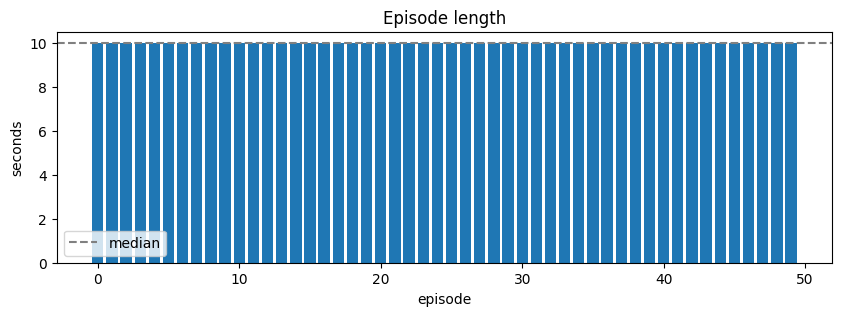

길이 이상 의심 에피소드: 없음


In [ ]:
# 에피소드 길이 그래프 — 중앙값의 0.5배 미만(빨강)이나 2배 초과(주황)는 잘리거나 머뭇거린 시연일 수 있으니 우선 검수
if lengths is not None:
    color_map = {"짧음": "tab:red", "김": "tab:orange", "": "tab:blue"}
    plt.figure(figsize=(10, 3))
    plt.bar(lengths["episode_index"], lengths["seconds"], color=lengths["flag"].map(color_map))
    plt.axhline(lengths["seconds"].median(), ls="--", c="gray", label="median")
    plt.xlabel("episode"); plt.ylabel("seconds"); plt.title("Episode length")
    plt.legend(); plt.show()

    flagged = lengths[lengths["flag"] != ""]
    print("길이 이상 의심 에피소드:", flagged["episode_index"].tolist() or "없음")

## 3. 검수

웹 뷰어(https://huggingface.co/spaces/lerobot/visualize_dataset)에 데이터셋 repo_id를 넣고 **50개 에피소드를 모두 재생**하며 확인한다.

**확인 항목**
1. 1-1에서 정한 성공 조건대로 태스크가 끝까지 성공했는가
2. 동작 시작 전에 시작해 완료 후에 끝나는가 (중간에 잘리지 않았는가)
3. 모든 카메라 영상이 정상인가 (검은 화면, 멈춤, 끊김 없음)
4. state·action 그래프가 동작에 맞게 움직이는가 (평평한 직선이 아닌가)

### 3-1. 에피소드별 검수표
`[작성]` 아래 셀의 `?`를 `O`(이상 없음) 또는 `X`(문제 있음)로 바꾸고, 필요하면 `|` 뒤에 메모를 적는다.
최종 제출 데이터셋은 **모든 에피소드가 `O`**여야 한다. `X`가 있으면 재녹화 후 다시 검수한다.

In [ ]:
REVIEW = """
 0 | O |
 1 | O |
 2 | O |
 3 | O |
 4 | O |
 5 | O |
 6 | O |
 7 | O |
 8 | O |
 9 | O |
10 | O |
11 | O |
12 | O |
13 | O |
14 | O |
15 | O |
16 | O |
17 | O |
18 | O |
19 | O |
20 | O |
21 | O |
22 | O |
23 | O |
24 | O |
25 | O |
26 | O |
27 | O |
28 | O |
29 | O |
30 | O |
31 | O |
32 | O |
33 | O |
34 | O |
35 | O |
36 | O |
37 | O |
38 | O |
39 | O |
40 | O |
41 | O |
42 | O |
43 | O |
44 | O |
45 | O |
46 | O |
47 | O |
48 | O |
49 | O |
"""

review_rows = []
for line in REVIEW.strip().splitlines():
    parts = [p.strip() for p in line.split("|")]
    review_rows.append({"episode": int(parts[0]), "result": parts[1],
                        "note": parts[2] if len(parts) > 2 else ""})
review_df = pd.DataFrame(review_rows)
print(review_df["result"].value_counts().to_string())
review_df[review_df["result"] != "O"]   # O가 아닌 행만 표시

result
O    50


,episode,result,note


### 3-2. 재녹화 기록
`[작성]` 수집·검수 과정에서 다시 녹화한 시연이 있었다면 몇 개를, 어떤 문제 때문에 다시 녹화했는지 적는다. (없으면 "없음")  
없음
-

## 4. 소감 및 과제 2 준비
`[작성]` 3~5문장으로 답한다.

**4-1.** 수집하면서 시연의 일관성을 유지하기 위해 신경 쓴 점은 무엇인가?  
리더암과 팔로워암의 위치가 흔들리지 않게 조심했다. 주변 사물에 의해 카메라를 통해 얻는 정보가 변하는 것을 방지하기 위해 주변 사물을 최대한 정리했다. 최대한 정확하고 깨끗한 데이터를 수집하기 위해 리더암 조작 시 쓸데없는 움직임이 들어가지 않도록 노력했다.

**4-2.** 이 데이터로 ACT를 학습했을 때 정책이 어려워할 것 같은 상황은 무엇이라고 예상하는가?  
단일 앵글 카메라를 활용하기 때문에 주변 조명이 바뀌거나 그림자가 생기면 어두운 물체를 식별하지 못할 수 있을 것 같다. 또한 집는 과정에서 집게와 물체 사이에서 미끄러짐이 발생할 수 있을 것 같다. 마지막으로 물체의 위치나 놓인 각도가 에피소드에서 벗어날 경우 잡기 동작에 실패할 수 있을 것 같다.

## 제출 전 체크리스트
아래 셀을 실행해 모든 항목이 통과하는지 확인한 뒤 커밋한다.

In [ ]:
check_items = {
    "데이터셋 접근 가능 (public)": len(repo_files) > 0,
    "에피소드 50개": bool(info) and info.get("total_episodes") == 50,
    "검수표 50개 에피소드 모두 기재": sorted(review_df["episode"]) == list(range(50)),
    "검수 결과 모두 O": (review_df["result"] == "O").all(),
    "태스크 문장이 TASK와 일치하고 영어로 작성됨": task_set == {TASK} and all(t.isascii() for t in task_set),
    "검수표와 데이터셋 에피소드 수 일치": bool(info) and len(review_df) == info.get("total_episodes"),
}
for k, v in check_items.items():
    print(("[통과] " if v else "[미흡] ") + k)
print("\n모두 통과" if all(check_items.values()) else "\n미흡 항목을 보완한 뒤 커밋할 것")

[통과] 데이터셋 접근 가능 (public)
[통과] 에피소드 50개
[통과] 검수표 50개 에피소드 모두 기재
[통과] 검수 결과 모두 O
[통과] 태스크 문장이 TASK와 일치하고 영어로 작성됨
[통과] 검수표와 데이터셋 에피소드 수 일치

모두 통과
